<a href="https://colab.research.google.com/github/SattuSupCodes/PythonJournal/blob/main/whatever.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons

Text(0.5, 1.0, 'make_moons')

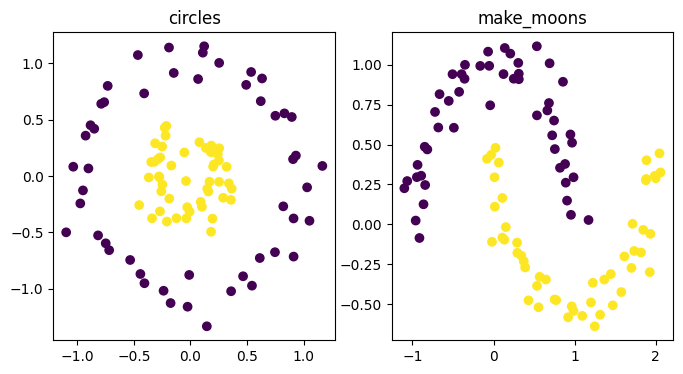

In [5]:
fig, (ax1,ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (8,4))
X,Y = make_circles(noise = 0.1, factor = 0.3, random_state = 0)
ax1.scatter(X[:, 0], X[:,1], c=Y)
ax1.set_title("circles")
X, Y = make_moons(noise=0.1, random_state=0)
ax2.scatter(X[:, 0], X[:, 1], c=Y)
ax2.set_title("make_moons")

just having fun with wtvr sklearn has to offer. This is of no out-of-the-box academic significance. Rather an attempt to find amusement in what the world finds mundane.

#Wine clustering


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harrywang/wine-dataset-for-clustering")

print("Path to dataset files:", path)

100%|██████████| 4.36k/4.36k [00:00<00:00, 1.20MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/harrywang/wine-dataset-for-clustering/versions/1


In [8]:
import os
path_file = os.path.join(path, "wine-clustering.csv")

print(path_file)


/root/.cache/kagglehub/datasets/harrywang/wine-dataset-for-clustering/versions/1/wine-clustering.csv


In [19]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [15]:
df = pd.read_csv(path_file)
print(df)

     Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0      14.23        1.71  2.43          15.6        127           2.80   
1      13.20        1.78  2.14          11.2        100           2.65   
2      13.16        2.36  2.67          18.6        101           2.80   
3      14.37        1.95  2.50          16.8        113           3.85   
4      13.24        2.59  2.87          21.0        118           2.80   
..       ...         ...   ...           ...        ...            ...   
173    13.71        5.65  2.45          20.5         95           1.68   
174    13.40        3.91  2.48          23.0        102           1.80   
175    13.27        4.28  2.26          20.0        120           1.59   
176    13.17        2.59  2.37          20.0        120           1.65   
177    14.13        4.10  2.74          24.5         96           2.05   

     Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0          3.06               

In [17]:
pca = PCA(n_components = 2)
data_pca = pca.fit_transform(df)

In [20]:
df_unscale = pd.DataFrame(data_pca, columns = ["PC1","PC2"])

scalar = StandardScaler()
scaled_data = scalar.fit_transform(df)
scaled_pca = pca.fit_transform(scaled_data)

In [21]:
kmeans = KMeans(n_clusters = 3, random_state=42)

In [22]:
kmeans.fit(scaled_pca)

KMeans(n_clusters=3, random_state=42)

In [25]:
labels = kmeans.labels_
df['clusters']=labels

Text(0.5, 1.0, 'Cluster visualization on scaled data')

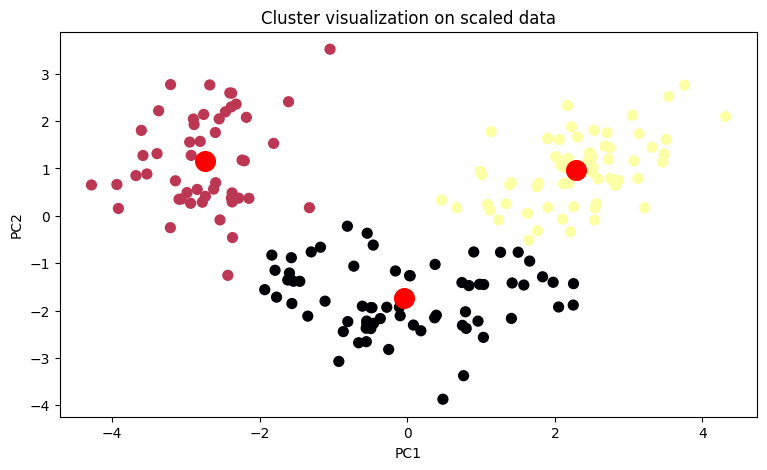

In [31]:
plt.figure(figsize=(9,5))
plt.scatter(scaled_pca[:,0],scaled_pca[:,1], c=labels, cmap='inferno',s=50)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],color='red',s=200)
plt.xlabel('PC1') #i cheated here only btw
plt.ylabel('PC2')
plt.title('Cluster visualization on scaled data')